# Error Analysis 

In [1]:
import logging 
import pandas as pd 
log_file = r"C:\Users\Rasulbekk\Desktop\Practise\Log\error_analysis.log"

In [3]:
logging.basicConfig(
    filename=log_file,
    filemode="a",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
    )


logging.info("Erorr Alaysis started")

In [4]:
import os 
import sys 
sys.path.append(r"C:\Users\Rasulbekk\Desktop\Practise\Source")

In [5]:
from data_loader import DataLoader

In [6]:
path = r"C:\Users\Rasulbekk\Desktop\Practise\Data"
loader = DataLoader(path)

In [7]:
df = loader.load_datasets()

In [9]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2022 entries, 0 to 2021
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          2022 non-null   int64  
 1   Unnamed: 0.2        2022 non-null   int64  
 2   name                2022 non-null   float64
 3   birth_date          2022 non-null   float64
 4   birth_place         2022 non-null   float64
 5   death_date          2022 non-null   float64
 6   death_place         2022 non-null   float64
 7   occupation          2022 non-null   float64
 8   awards              2022 non-null   float64
 9   alma_mater          2022 non-null   float64
 10  education           2022 non-null   float64
 11  spouse              2022 non-null   float64
 12  children            2022 non-null   float64
 13  occupation_cluster  2022 non-null   float64
 14  birth_year          2022 non-null   float64
 15  death_year          2022 non-null   float64
 16  life_span        

In [10]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

In [11]:
num_cols = df.select_dtypes(include=[np.number]).columns.drop('life_span').tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

In [12]:
for col in cat_cols:
    df[col] = df[col].astype(str)

In [13]:
if 'life_span' not in df.columns:
    print("ushbu 'life_span' nomli ustun  topilamdi")
    print(df.columns.tolist())
else:
    x = df.drop('life_span', axis=1) 
    y = df['life_span']

In [14]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="mean")),
    ('scaler', MinMaxScaler())
])

In [15]:
num_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'mean'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a fea

In [16]:
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('encoder', OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])



In [17]:
cat_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('encoder', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation

In [19]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

In [20]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [21]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

In [22]:
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [23]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [24]:
pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [25]:
y_pred = pipeline.predict(x_test)

In [26]:
y_pred

array([5.56700000e+01, 6.73000000e+01, 6.02007105e+01, 3.14310000e+02,
       5.12620071e+01, 6.02007105e+01, 8.35200000e+01, 8.46400000e+01,
       6.02007105e+01, 5.97587034e+01, 6.02007105e+01, 6.02007105e+01,
       7.04300000e+01, 7.78500000e+01, 5.86700000e+01, 7.39700000e+01,
       3.03800000e+01, 7.17100000e+01, 5.72200000e+01, 7.15300000e+01,
       8.68500000e+01, 6.38200000e+01, 6.73000000e+01, 8.47700000e+01,
       6.02007105e+01, 5.94800000e+01, 6.02007105e+01, 6.67600000e+01,
       6.02007105e+01, 8.12800000e+01, 1.18354050e+02, 6.00487034e+01,
       6.00426821e+01, 6.02007105e+01, 7.85800000e+01, 6.59900000e+01,
       6.02007105e+01, 6.02007105e+01, 6.02007105e+01, 5.91300000e+01,
       3.04500000e+01, 3.74300000e+01, 6.02007105e+01, 6.02007105e+01,
       6.02007105e+01, 4.65400000e+01, 9.00300000e+01, 6.00460568e+01,
       5.25500000e+01, 6.02007105e+01, 6.59900000e+01, 4.18600000e+01,
       6.02007105e+01, 4.16700000e+01, 7.00200000e+01, 9.98500000e+01,
      

In [27]:
from sklearn.metrics import r2_score, mean_absolute_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R2 natijasi: ", r2)
print("MAE natijasi: ", mae)

R2 natijasi:  0.6759366634990901
MAE natijasi:  5.6395991053220325


In [28]:
print(f"R2 natijasi:{r2:.2f}")
print(f"MAE natijasi: {mae:.2f}")

R2 natijasi:0.68
MAE natijasi: 5.64


# Error Anaylsis 

In [30]:
import numpy as np 

errors = y_test - y_pred
abs_errors = np.abs(errors)

import pandas as pd 

erorrs_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted' : y_pred,
    'Error':errors,
    'Absolute Error': abs_errors
})

print(erorrs_df.head(10))

         Actual   Predicted         Error  Absolute Error
674    58.00000   55.670000  2.330000e+00    2.330000e+00
1384   68.00000   67.300000  7.000000e-01    7.000000e-01
720    60.20071   60.200710 -4.973799e-14    4.973799e-14
590   391.00000  314.310000  7.669000e+01    7.669000e+01
576    42.00000   51.262007 -9.262007e+00    9.262007e+00
1285   60.20071   60.200710 -4.263256e-14    4.263256e-14
128    83.00000   83.520000 -5.200000e-01    5.200000e-01
1456   85.00000   84.640000  3.600000e-01    3.600000e-01
1302   60.20071   60.200710 -4.973799e-14    4.973799e-14
1887   60.20071   59.758703  4.420071e-01    4.420071e-01


In [31]:
erorrs_df = erorrs_df.reset_index(drop=True)
x_test_reset = x_test.reset_index(drop=True)

In [32]:
full_errors_df = pd.concat([x_test_reset, erorrs_df],axis=1)

In [33]:
print(full_errors_df.head())

   Unnamed: 0  Unnamed: 0.2      name  birth_date  birth_place  death_date  \
0         674           674  1.495078    0.816544    -0.913363    0.795380   
1        1384          1384  0.209820   -1.284747    -0.872143   -0.512415   
2         720           720  1.464580    0.340508     0.245946   -0.842735   
3         590           590 -1.145146   -1.039516    -0.702111   -0.964077   
4         576           576 -0.182292   -0.318249     1.286747    0.101035   

   death_place  occupation    awards  alma_mater  ...  birth_year  \
0    -0.556294    1.270017  0.391234   -0.279288  ...      1865.0   
1    -1.081019   -0.594135  0.391234   -0.279288  ...      1856.0   
2    -0.690047   -0.513085 -2.776040    4.055307  ...      1952.0   
3     0.277094    0.994447  0.391234   -0.993222  ...      1984.0   
4     2.262819   -0.205094  0.391234    0.536635  ...      1775.0   

    death_year  life_span_cluster  edu_award_cluster  bio_cluster  \
0  1923.000000            2.00000          -0.5

In [34]:
print(full_errors_df.columns)

Index(['Unnamed: 0', 'Unnamed: 0.2', 'name', 'birth_date', 'birth_place',
       'death_date', 'death_place', 'occupation', 'awards', 'alma_mater',
       'education', 'spouse', 'children', 'occupation_cluster', 'birth_year',
       'death_year', 'life_span_cluster', 'edu_award_cluster', 'bio_cluster',
       'source_file', 'Actual', 'Predicted', 'Error', 'Absolute Error'],
      dtype='str')


In [39]:
error_cols = full_errors_df[['children', "Error", "Absolute Error"]]
print(error_cols.head(10))

   children         Error  Absolute Error
0  2.151473  2.330000e+00    2.330000e+00
1  3.825086  7.000000e-01    7.000000e-01
2  1.823314 -4.973799e-14    4.973799e-14
3 -0.408171  7.669000e+01    7.669000e+01
4 -0.408171 -9.262007e+00    9.262007e+00
5 -0.408171 -4.263256e-14    4.263256e-14
6  1.298258 -5.200000e-01    5.200000e-01
7 -0.408171  3.600000e-01    3.600000e-01
8 -0.408171 -4.973799e-14    4.973799e-14
9 -0.408171  4.420071e-01    4.420071e-01


# Worst Prediction

In [41]:
worst_predictions = full_errors_df.sort_values(by="Absolute Error", ascending=False).head(10)
print("Eng yamon 10 ta Predcition")
display(worst_predictions[['Actual', "Predicted", "Error", "Absolute Error"]])

Eng yamon 10 ta Predcition


,Actual,Predicted,Error,Absolute Error
202,918.00000,320.304298,597.695702,597.695702
105,918.00000,320.304298,597.695702,597.695702
199,914.00000,745.758064,168.241936,168.241936
3,391.00000,314.310000,76.690000,76.690000
340,0.00000,62.250000,-62.250000,62.250000
347,60.20071,122.052504,-61.851794,61.851794
30,68.00000,118.354050,-50.354050,50.354050
292,0.00000,31.738099,-31.738099,31.738099
338,196.00000,225.890000,-29.890000,29.890000
230,60.20071,87.050604,-26.849893,26.849893


# Errors Distribution

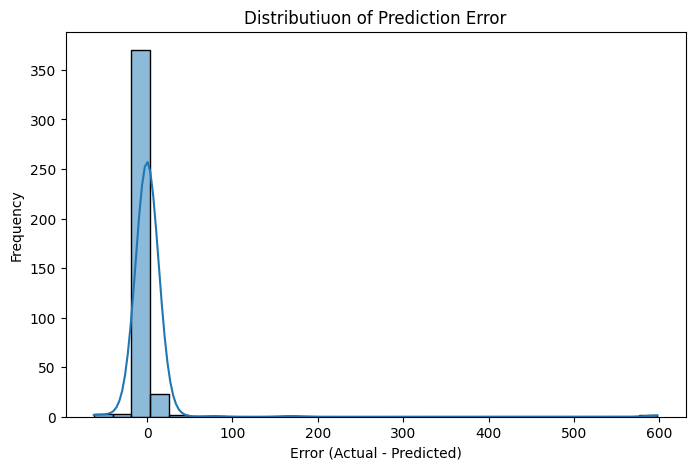

In [42]:
import matplotlib.pyplot as plt 
import seaborn as sns 

plt.figure(figsize=(8, 5))
sns.histplot(errors, bins=30, kde=True)
plt.title("Distributiuon of Prediction Error")
plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.show()


# Actual va Predicted

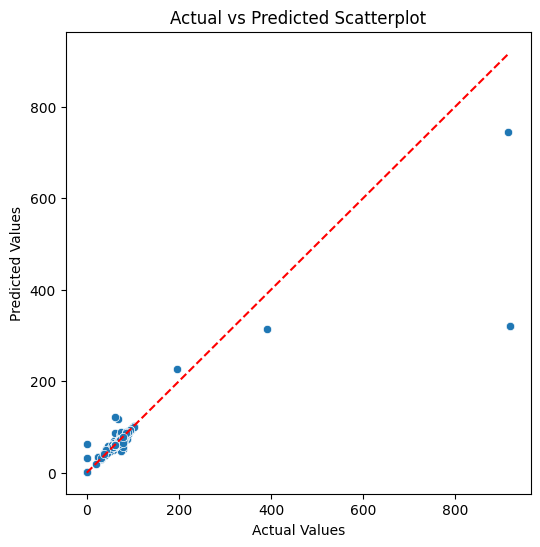

In [43]:
import matplotlib.pyplot as plt 
import seaborn as sns 

plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Scatterplot")
plt.show()
